Создать приложение по распознаванию лиц 5 известных персон: Билла Гейтса, Илона Маска, Джефа Безоса, Марка Цукерберга, Стива Джобса

Что нужно будет сделать:

1 Скачать и загрузить датасет https://drive.google.com/file/d/120xqh0mYtYZ1Qh7vr-XFzjPbSKivLJjA/view.
2 Отрисовать один батч загруженных данных.
3 Выбрать предобученную модель.
4 Обучить многоклассовый классификатор, используя выбранную модель.
5 Визуализировать предсказания модели.
6 Описать полученные результаты в текстовой ячейке ноутбука.

Основная цель ─ добиться accuracy > 0.85 на валидационной выборке и визуализировать результаты.

In [1]:
import os
import torch
import random
import numpy as np
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from tqdm import tqdm
from PIL import Image
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder

%matplotlib inline
BATCH_SIZE = 16

In [2]:
# Определяем используемый девайс
use_gpu = torch.cuda.is_available()
device = 'cuda' if use_gpu else 'cpu'
print('Connected device:', device)

Connected device: cpu


In [3]:
# Функция вывода картинок.  
def plot_samples(dataset, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(2 * num_samples, 1.5))
    for i in range(num_samples):
        random_image, random_class = random.choice(dataset)
        random_label = dataset.classes[random_class]
        axes[i].imshow(random_image)
        axes[i].set_title(random_label.replace("_", " ").title())
        axes[i].axis('off')
    plt.show()

train


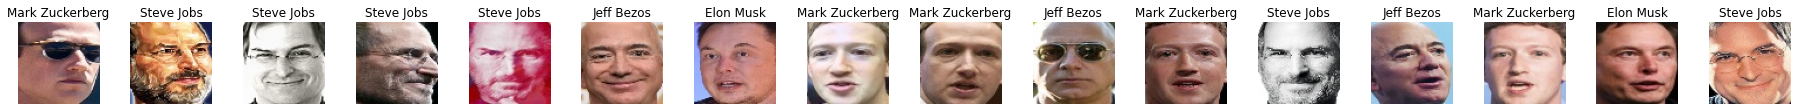

valid


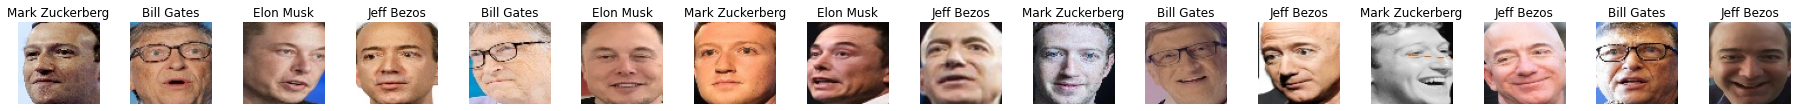

In [4]:
# Выводим один батч картинок из обучающей и валидационной выборки
print('train')
plot_samples(ImageFolder('data/train/'), BATCH_SIZE)
print('valid')
plot_samples(ImageFolder('data/valid/'), BATCH_SIZE)

In [5]:
# Создаем обучающий датасет  
train_dataset = ImageFolder(
    root='data/train'
)
# Создаем валидационный датасет  
valid_dataset = ImageFolder(
    root='data/valid'
)

In [6]:
# Препроцессинг данных train и valid
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

train_dataset.transform = transforms.Compose([
    transforms.Resize([70, 70]),
    transforms.RandomHorizontalFlip(), # случайное отображение по горизонтали (зеркально)
    transforms.RandomAutocontrast(),   # улучшение контраста случайным образом
    transforms.RandomEqualize(),       # гистограммное выравнивание яркости
    transforms.ToTensor(),             # преодразование в тензор 
    normalize
])

valid_dataset.transform = transforms.Compose([
    transforms.Resize([70, 70]),
    transforms.ToTensor(),
    normalize
])

# Загрузчик для обучающих данных  
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, 
    shuffle=True 
)
# Загрузчик для валидационных данных  
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, 
    shuffle=False 
)

In [7]:
# Используем предварительно обученную модель vgg16
from torchvision.models import vgg16, VGG16_Weights
model = vgg16(weights=VGG16_Weights.DEFAULT)   
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [8]:
# Для заморозки выполняем  фиксацию весов модели во время обретного распространения ошибки 
import torch.nn as nn
for param in model.parameters():
    param.requires_grad = False

# Определяем число нейронов на входе выходного слоя классификатора
n_neurons = model.classifier[-1].in_features 
print(n_neurons)

# Заменим этот слой на новый, выходное количество нейронов которого соотвествует нашей задачи бинарной классификации
num_classes = 5
model.classifier[-1] = nn.Linear(n_neurons, num_classes)

4096


In [9]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=5, bias=True)
)

In [10]:
# Обеспечиваем обучение только выходного слоя классификатора
for index, param in enumerate(model.classifier.parameters()):
    if index == 6:
        param.requires_grad = True

In [11]:
# Функция для обучения и валидации 
def train(model, optimizer, train_loader, val_loader, epoch=10):
    loss_train, acc_train = [], []
    loss_valid, acc_valid = [], []
    for epoch in tqdm(range(epoch)):
        losses, equals = [], []
        torch.set_grad_enabled(True)
        
        # Train.  
        model.train()
        for i, (image, target) in enumerate(train_loader):
            image = image.to(device)
            target = target.to(device)
            output = model(image)
            loss = criterion(output,target)

            losses.append(loss.item())
            equals.extend(
                [x.item() for x in torch.argmax(output, 1) == target])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        loss_train.append(np.mean(losses))
        acc_train.append(np.mean(equals))
        losses, equals = [], []
        torch.set_grad_enabled(False)

        # Validate.  
        model.eval()
        for i , (image, target) in enumerate(valid_loader):
            image = image.to(device)
            target = target.to(device)

            output = model(image)
            loss = criterion(output,target)

            losses.append(loss.item())
            equals.extend(
                [y.item() for y in torch.argmax(output, 1) == target])

        loss_valid.append(np.mean(losses))
        acc_valid.append(np.mean(equals))
        
    return loss_train, acc_train, loss_valid, acc_valid

In [12]:
# Задаем показатель вычисления потерь
criterion = torch.nn.CrossEntropyLoss()
criterion = criterion.to(device)

In [13]:
# Функция вывода графиков.  
def plot_chart(loss_t, loss_v, acc_t, acc_v):
    m_val = str(max(acc_v).round(4))
    plt.figure(figsize=(12, 4),facecolor='lightblue')
    len_l = range(len(loss_t))
    for i in range(121, 123):
        lst = [loss_t, loss_v, 'Loss', 'Epochs'] if i==121 else \
            [acc_t, acc_v, 'Accuracy', 'Epochs\n\nValidate accuracy: '+m_val]
        plt.subplot(i)
        plt.plot(len_l, lst[0],'o-', color='b', label='train')
        plt.plot(len_l, lst[1],'o-', color='r', label='valid')
        plt.legend(fontsize=10, edgecolor='red', labelcolor='#9E1316')
        plt.grid()
        plt.title(lst[2])
        plt.xlabel(lst[3])
    plt.show();

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [50:14<00:00, 75.37s/it]


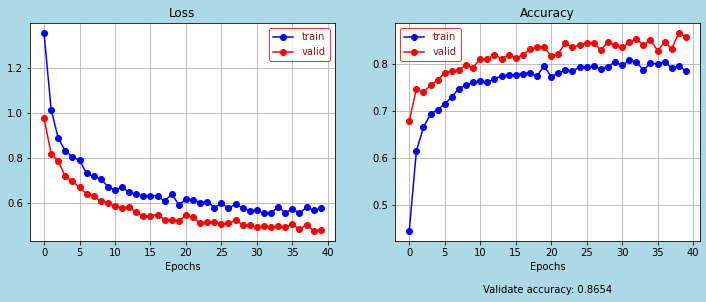

In [14]:
# Задаем алгоритм оптимизации и скорость обновления параметров модели
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model = model.to(device)
# Обучение модели
loss_train, acc_train, loss_valid, acc_valid = train(
model, optimizer, train_loader, valid_loader, 40)
# Отображение результатов
plot_chart(loss_train, loss_valid, acc_train, acc_valid);

torch.cuda.empty_cache()

In [17]:
# Функция вывода тестовых картинок и предсказаний.  
def face_predict(model, face):
    plt.figure(figsize=(15, 3))
    for i, name in enumerate(face_lst):
        image = Image.open(name[1]).convert('RGB')
        tensor = valid_dataset.transform(image)
        batch = torch.stack([tensor])
        with torch.no_grad():
            x = model(batch.to(device)).to(device)
        pred = x.argmax().item()
        pred_title = train_dataset.classes[pred].replace('_', ' ').title()
        plt.subplot(1, len(face_lst), i+1)
        plt.title(str(i+1)+':  '+name[0])
        plt.imshow(image)
        plt.xlabel('\n'+'predict:\n'+pred_title, c='g', fontsize=11)
    plt.show();

In [18]:
# Список для предсказаний -  по одной картинке из валидационных данных для каждой персоны
face_lst=[
    ["Bill Gates",'data/valid/bill_gates/bccc958f-f13a-4a92-a803-7bd75b4d0da9.jpg'],
    ["Elon Musk",'data/valid/elon_musk/c19d502c-907d-4fd1-9b29-82c3c7c3be69.jpg'],
    ["Jeff Besoz",'data/valid/jeff_bezos/bdfcc4a7-ca7a-47e5-bee7-b6d90c8ea1f9.jpg'], 
    ["Mark Zuckerberg", 'data/valid/mark_zuckerberg/c0713ac0-ae86-41a3-8f5b-b5b91296e53a.jpg'], 
    ["Steve Jobs",'data/valid/steve_jobs/de5c0758-b72e-4513-a11a-e151d99a81b2.jpg']
]


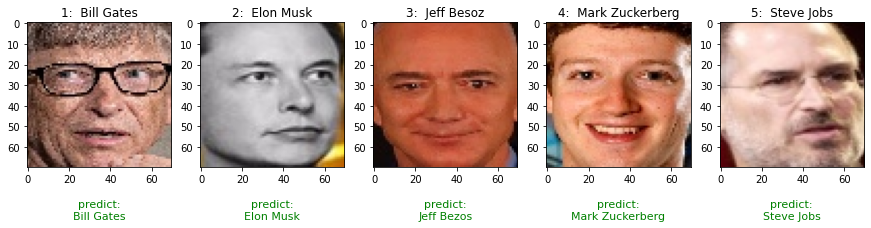

In [19]:
# Предсказания на валидационных данных
face_predict(model, face_lst);

 Разработан классификатор с использованием предварительно обученной сети  vgg16. При настройке были заморожены все слои, кроме последнего.
Обучение проводилось на 40 эпохах при скорости обучения 0.0001. Достигнута точночть accuracy на валидационной выборке 0.865, что подтверждает выполнение основного требования задания ( превышение accuracy 0.85).
Для улучшения результата можно провести работу по следующим направлениям: использовать другие предварительно обученные сети, заморозить меньшее число слоев, использовать картинки большего формата.